In [1]:
import cv2
import numpy as np
from PIL import Image, ImageFilter
from collections import Counter
from gradio_client import Client, handle_file


# Set your input path
INPUT_IMAGE = "../data/test.png"# Make sure this file exists

# --- STEP 1: INITIAL CLOUD SEGMENTATION (CLEAN) ---
# We use the unwatermarked BRIA model hosted in the cloud
client = Client("briaai/BRIA-RMBG-1.4")

print(f"[-] Getting initial cutout for: {INPUT_IMAGE}")
result_file = client.predict(handle_file(INPUT_IMAGE), api_name="/predict")

# Read the transparent result as an OpenCV image (RGBA)
raw_cutout = cv2.imread(result_file, cv2.IMREAD_UNCHANGED)

if raw_cutout is None:
    raise RuntimeError("Failed to load cloud result. Make sure input path is correct.")

# --- STEP 2: ALPHA MASK CLEANUP LOGIC (REMOVING DEBRIS) ---
print(f"[-] Cleaning alpha mask using contour area filtering...")
alpha = raw_cutout[:, :, 3]

# Create a binary threshold from alpha
_, thresh = cv2.threshold(alpha, 10, 255, cv2.THRESH_BINARY)

# Fill holes inside the pot caused by pattern confusion (Morphological Close)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
closed_mask = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

# Find all disconnected blobs (pot vs debris)
contours, _ = cv2.findContours(closed_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contours:
    # 1. Identify the largest blob by area (this is the main pot)
    largest_contour = max(contours, key=cv2.contourArea)

    # 2. Create a clean, sterile mask containing ONLY the pot
    clean_mask = np.zeros_like(alpha)
    cv2.drawContours(clean_mask, [largest_contour], -1, 255, thickness=cv2.FILLED)

    # 3. Add a slight Gaussian blur to the mask edges for smooth integration
    clean_mask = cv2.GaussianBlur(clean_mask, (5, 5), 0)

    # 4. Re-apply this sterile mask to the original cutout
    # This algorithmically discards all debris (wrappers, cap, dirt)
    raw_cutout[:, :, 3] = clean_mask
    print("[+] Successfully filtered debris using Contour Area Analysis.")
else:
    print("!!! Error: No contours found in segmentation mask.")

# --- STEP 3: PIL INTEGRATION & STUDIO PIPELINE ---
# Convert the OpenCV BGRA image to PIL RGBA
clean_cutout_pil = Image.fromarray(cv2.cvtColor(raw_cutout, cv2.COLOR_BGRA2RGBA))

# Execute the dynamic background and shadow logic from earlier turns
print(f"[-] Compositing clean cutout onto dynamic studio backdrop...")

np_img = np.array(clean_cutout_pil)
visible = np_img[np_img[:, :, 3] > 128][:, :3]

quantized = (visible // 32) * 32
counts = Counter(map(tuple, quantized))
dominant_rgb = np.array(counts.most_common(1)[0][0], dtype=np.float32)

base_bg = 0.85 * 255.0 + 0.15 * dominant_rgb
top_color = np.clip(base_bg - 12.0, 0, 255).astype(np.float32)
bottom_color = np.clip(base_bg + 8.0, 0, 255).astype(np.float32)

gradient = np.linspace(top_color, bottom_color, 1024)[:, None, :]
canvas = Image.fromarray(np.repeat(gradient, 1024, axis=1).astype(np.uint8)).convert("RGBA")

clean_cutout_pil.thumbnail((760, 760), Image.Resampling.LANCZOS)
w, h = clean_cutout_pil.size

shadow_mask = clean_cutout_pil.split()[-1].filter(ImageFilter.GaussianBlur(16))
shadow = Image.new("RGBA", (w, h), (40, 40, 40, 50))

paste_x = (1024 - w) // 2
paste_y = (1024 - h) // 2
shadow_offset = int(h * 0.03) + 10

canvas.paste(shadow, (paste_x, paste_y + shadow_offset), mask=shadow_mask)
canvas.paste(clean_cutout_pil, (paste_x, paste_y), mask=clean_cutout_pil.split()[-1])

# --- STEP 4: OUTPUT ---
final_clean_catalog = canvas.convert("RGB")
output_filename = "fixed_studio_catalog.jpg"
final_clean_catalog.save(output_filename)
print(f"SUCCESS: Catalog-ready image saved as '{output_filename}' without artifacts.")
final_clean_catalog.show()

Loaded as API: https://briaai-bria-rmbg-1-4.hf.space
[-] Getting initial cutout for: ../data/test.png
[-] Cleaning alpha mask using contour area filtering...
[+] Successfully filtered debris using Contour Area Analysis.
[-] Compositing clean cutout onto dynamic studio backdrop...
SUCCESS: Catalog-ready image saved as 'fixed_studio_catalog.jpg' without artifacts.


In [2]:
import os
import cv2
import time
import uuid
import numpy as np
from PIL import Image, ImageFilter
from collections import Counter
from typing import TypedDict, List, Optional
from pydantic import BaseModel, Field, field_validator
from gradio_client import Client, handle_file
from langgraph.graph import StateGraph, END

# ==========================================
# 1. Target Pydantic Models
# ==========================================

class ImageMetadata(BaseModel):
    image_index: int
    original_path: str
    processed_path: str
    dominant_color_hex: str
    processing_time_sec: float

class BatchCatalogResult(BaseModel):
    batch_id: str = Field(default_factory=lambda: f"batch_{uuid.uuid4().hex[:8]}")
    images: List[str] = Field(..., max_length=5, description="Flat list of output paths matching target payload")
    image_details: List[ImageMetadata]
    total_duration_sec: float

    @field_validator("images")
    @classmethod
    def validate_batch_size(cls, v):
        if len(v) > 5:
            raise ValueError("Pipeline strictly accepts a maximum of 5 images.")
        return v

# ==========================================
# 2. LangGraph State Definition
# ==========================================

class BatchState(TypedDict):
    input_paths: List[str]
    current_index: int
    processed_paths: List[str]
    image_details: List[dict]
    final_output: Optional[BatchCatalogResult]
    error: Optional[str]

# Workspace setup
OUTPUT_DIR = "catalog_batch_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)
bg_client = Client("briaai/BRIA-RMBG-1.4")

# ==========================================
# 3. Robust Image Processing Function
# ==========================================

def process_single_image(img_path: str, index: int) -> dict:
    t0 = time.time()

    if not os.path.exists(img_path):
        raise FileNotFoundError(f"Image not found at {img_path}")

    # 1. Cloud RMBG Cutout
    result_file = bg_client.predict(handle_file(img_path), api_name="/predict")
    raw_cutout = cv2.imread(result_file, cv2.IMREAD_UNCHANGED)
    if raw_cutout is None:
        raise ValueError(f"Failed to read cutout from {img_path}")

    # 2. OpenCV Contour & Debris Filtering
    alpha = raw_cutout[:, :, 3]
    _, thresh = cv2.threshold(alpha, 10, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    closed_mask = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(closed_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        raise ValueError(f"No product contour detected in {img_path}")

    largest_contour = max(contours, key=cv2.contourArea)
    clean_mask = np.zeros_like(alpha)
    cv2.drawContours(clean_mask, [largest_contour], -1, 255, thickness=cv2.FILLED)
    clean_mask = cv2.GaussianBlur(clean_mask, (5, 5), 0)
    raw_cutout[:, :, 3] = clean_mask

    # 3. PIL Conversion & Tone Extraction (Filtering extreme blacks/whites)
    clean_cutout_pil = Image.fromarray(cv2.cvtColor(raw_cutout, cv2.COLOR_BGRA2RGBA))
    np_img = np.array(clean_cutout_pil)

    # Filter for visible, non-neutral pixels (avoid picking black shadow or white glare)
    visible_mask = np_img[:, :, 3] > 160
    visible_rgb = np_img[visible_mask][:, :3]

    brightness = np.mean(visible_rgb, axis=1)
    chroma_mask = (brightness > 30) & (brightness < 235)
    filtered_rgb = visible_rgb[chroma_mask] if np.any(chroma_mask) else visible_rgb

    quantized = (filtered_rgb // 32) * 32
    dominant_rgb = np.array(Counter(map(tuple, quantized)).most_common(1)[0][0], dtype=np.float32)
    dominant_hex = "#{:02x}{:02x}{:02x}".format(int(dominant_rgb[0]), int(dominant_rgb[1]), int(dominant_rgb[2]))

    # 4. Studio Background Canvas (1024x1024)
    canvas_size = 1024
    base_bg = 0.88 * 255.0 + 0.12 * dominant_rgb
    top_color = np.clip(base_bg - 10.0, 0, 255).astype(np.float32)
    bottom_color = np.clip(base_bg + 6.0, 0, 255).astype(np.float32)

    gradient = np.linspace(top_color, bottom_color, canvas_size)[:, None, :]
    canvas = Image.fromarray(np.repeat(gradient, canvas_size, axis=1).astype(np.uint8)).convert("RGBA")

    # 5. Fit & Centered Contact Shadow
    clean_cutout_pil.thumbnail((760, 760), Image.Resampling.LANCZOS)
    w, h = clean_cutout_pil.size

    shadow_mask = clean_cutout_pil.split()[-1].filter(ImageFilter.GaussianBlur(14))
    shadow = Image.new("RGBA", (w, h), (35, 35, 35, 60))
    paste_x = (canvas_size - w) // 2
    paste_y = (canvas_size - h) // 2
    shadow_offset = int(h * 0.02) + 8

    canvas.paste(shadow, (paste_x, paste_y + shadow_offset), mask=shadow_mask)
    canvas.paste(clean_cutout_pil, (paste_x, paste_y), mask=clean_cutout_pil.split()[-1])

    final_catalog_path = os.path.join(OUTPUT_DIR, f"image{index}_processed.jpg")
    canvas.convert("RGB").save(final_catalog_path, quality=95)

    return {
        "image_index": index,
        "original_path": img_path,
        "processed_path": final_catalog_path,
        "dominant_color_hex": dominant_hex,
        "processing_time_sec": round(time.time() - t0, 2)
    }

# ==========================================
# 4. Graph Nodes & Conditional Routing
# ==========================================

def validate_inputs_node(state: BatchState) -> BatchState:
    paths = state["input_paths"]
    if not paths:
        state["error"] = "No input image paths provided."
    elif len(paths) > 5:
        print(f"[!] Warning: Received {len(paths)} images. Capping batch to top 5.")
        state["input_paths"] = paths[:5]
    state["current_index"] = 0
    state["processed_paths"] = []
    state["image_details"] = []
    return state

def process_current_image_node(state: BatchState) -> BatchState:
    idx = state["current_index"]
    path = state["input_paths"][idx]
    print(f"[-] Processing Image [{idx + 1}/{len(state['input_paths'])}]: {path}")

    try:
        item = process_single_image(path, idx + 1)
        state["processed_paths"].append(item["processed_path"])
        state["image_details"].append(item)
    except Exception as e:
        state["error"] = f"Failed processing '{path}': {str(e)}"

    state["current_index"] = idx + 1
    return state

def route_next_image(state: BatchState) -> str:
    if state.get("error"):
        return "finalize"
    if state["current_index"] < len(state["input_paths"]):
        return "process_image"
    return "finalize"

def finalize_batch_node(state: BatchState) -> BatchState:
    if state.get("error"):
        print(f"[!] Pipeline halted with error: {state['error']}")
        return state

    validated_items = [ImageMetadata(**detail) for detail in state["image_details"]]
    total_time = sum(item.processing_time_sec for item in validated_items)

    state["final_output"] = BatchCatalogResult(
        images=state["processed_paths"],
        image_details=validated_items,
        total_duration_sec=round(total_time, 2)
    )
    return state

# ==========================================
# 5. Compile the Pipeline
# ==========================================

builder = StateGraph(BatchState)

builder.add_node("validate_inputs", validate_inputs_node)
builder.add_node("process_image", process_current_image_node)
builder.add_node("finalize", finalize_batch_node)

builder.set_entry_point("validate_inputs")
builder.add_edge("validate_inputs", "process_image")
builder.add_conditional_edges("process_image", route_next_image, {
    "process_image": "process_image",
    "finalize": "finalize"
})
builder.add_edge("finalize", END)

catalog_batch_pipeline = builder.compile()

# ==========================================
# 6. Execute (Up to 4-5 images)
# ==========================================

input_files = [
    "../data/test.png",
    # Add other paths here if present
]

initial_state: BatchState = {
    "input_paths": input_files,
    "current_index": 0,
    "processed_paths": [],
    "image_details": [],
    "final_output": None,
    "error": None
}

output_state = catalog_batch_pipeline.invoke(initial_state)

if output_state.get("final_output"):
    print("\n--- Processed Image Batch Result ---")
    print(output_state["final_output"].model_dump_json(indent=2))

Loaded as API: https://briaai-bria-rmbg-1-4.hf.space
[-] Processing Image [1/1]: ../data/test.png

--- Processed Image Batch Result ---
{
  "batch_id": "batch_3a96ddfa",
  "images": [
    "catalog_batch_output\\image1_processed.jpg"
  ],
  "image_details": [
    {
      "image_index": 1,
      "original_path": "../data/test.png",
      "processed_path": "catalog_batch_output\\image1_processed.jpg",
      "dominant_color_hex": "#400000",
      "processing_time_sec": 128.7
    }
  ],
  "total_duration_sec": 128.7
}


In [3]:
builder

In [4]:
import os
import cv2
import time
import uuid
import numpy as np
from PIL import Image, ImageFilter
from collections import Counter
from typing import TypedDict, List, Optional
from pydantic import BaseModel, Field, field_validator
from gradio_client import Client, handle_file
from langgraph.graph import StateGraph, END

# ==========================================
# 1. Pydantic Models
# ==========================================

class ImageMetadata(BaseModel):
    image_index: int
    original_path: str
    processed_path: str
    dominant_color_hex: str
    processing_time_sec: float

class BatchCatalogResult(BaseModel):
    batch_id: str = Field(default_factory=lambda: f"batch_{uuid.uuid4().hex[:8]}")
    images: List[str] = Field(..., max_length=5)
    image_details: List[ImageMetadata]
    total_duration_sec: float

    @field_validator("images")
    @classmethod
    def validate_batch_size(cls, v):
        if len(v) > 5:
            raise ValueError("Pipeline strictly accepts a maximum of 5 images.")
        return v

# ==========================================
# 2. State & Setup
# ==========================================

class BatchState(TypedDict):
    input_paths: List[str]
    current_index: int
    processed_paths: List[str]
    image_details: List[dict]
    final_output: Optional[BatchCatalogResult]
    error: Optional[str]

OUTPUT_DIR = "catalog_batch_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)
bg_client = Client("briaai/BRIA-RMBG-1.4")

# ==========================================
# 3. Processing Function
# ==========================================

def process_single_image(img_path: str, index: int) -> dict:
    t0 = time.time()

    # 1. Segmentation
    result_file = bg_client.predict(handle_file(img_path), api_name="/predict")
    raw_cutout = cv2.imread(result_file, cv2.IMREAD_UNCHANGED)
    if raw_cutout is None:
        raise ValueError(f"Failed to read cutout from {img_path}")

    # 2. Debris filter & hole healing
    alpha = raw_cutout[:, :, 3]
    _, thresh = cv2.threshold(alpha, 10, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    closed_mask = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(closed_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        raise ValueError(f"No product contour detected in {img_path}")

    largest_contour = max(contours, key=cv2.contourArea)
    clean_mask = np.zeros_like(alpha)
    cv2.drawContours(clean_mask, [largest_contour], -1, 255, thickness=cv2.FILLED)
    clean_mask = cv2.GaussianBlur(clean_mask, (5, 5), 0)
    raw_cutout[:, :, 3] = clean_mask

    # 3. Tone sampling
    clean_cutout_pil = Image.fromarray(cv2.cvtColor(raw_cutout, cv2.COLOR_BGRA2RGBA))
    np_img = np.array(clean_cutout_pil)

    visible_mask = np_img[:, :, 3] > 160
    visible_rgb = np_img[visible_mask][:, :3]
    brightness = np.mean(visible_rgb, axis=1)
    chroma_mask = (brightness > 30) & (brightness < 235)
    filtered_rgb = visible_rgb[chroma_mask] if np.any(chroma_mask) else visible_rgb

    quantized = (filtered_rgb // 32) * 32
    dominant_rgb = np.array(Counter(map(tuple, quantized)).most_common(1)[0][0], dtype=np.float32)
    dominant_hex = "#{:02x}{:02x}{:02x}".format(int(dominant_rgb[0]), int(dominant_rgb[1]), int(dominant_rgb[2]))

    # 4. Dynamic studio canvas & shadow
    canvas_size = 1024
    base_bg = 0.88 * 255.0 + 0.12 * dominant_rgb
    top_color = np.clip(base_bg - 10.0, 0, 255).astype(np.float32)
    bottom_color = np.clip(base_bg + 6.0, 0, 255).astype(np.float32)

    gradient = np.linspace(top_color, bottom_color, canvas_size)[:, None, :]
    canvas = Image.fromarray(np.repeat(gradient, canvas_size, axis=1).astype(np.uint8)).convert("RGBA")

    clean_cutout_pil.thumbnail((760, 760), Image.Resampling.LANCZOS)
    w, h = clean_cutout_pil.size

    shadow_mask = clean_cutout_pil.split()[-1].filter(ImageFilter.GaussianBlur(14))
    shadow = Image.new("RGBA", (w, h), (35, 35, 35, 60))
    paste_x = (canvas_size - w) // 2
    paste_y = (canvas_size - h) // 2
    shadow_offset = int(h * 0.02) + 8

    canvas.paste(shadow, (paste_x, paste_y + shadow_offset), mask=shadow_mask)
    canvas.paste(clean_cutout_pil, (paste_x, paste_y), mask=clean_cutout_pil.split()[-1])

    final_catalog_path = os.path.join(OUTPUT_DIR, f"image{index}_processed.jpg")
    canvas.convert("RGB").save(final_catalog_path, quality=95)

    return {
        "image_index": index,
        "original_path": img_path,
        "processed_path": final_catalog_path,
        "dominant_color_hex": dominant_hex,
        "processing_time_sec": round(time.time() - t0, 2)
    }

# ==========================================
# 4. Graph Nodes & Routing
# ==========================================

def validate_inputs_node(state: BatchState) -> BatchState:
    paths = state["input_paths"]
    if not paths:
        state["error"] = "No input image paths provided."
    elif len(paths) > 5:
        state["input_paths"] = paths[:5]
    state["current_index"] = 0
    state["processed_paths"] = []
    state["image_details"] = []
    return state

def process_current_image_node(state: BatchState) -> BatchState:
    idx = state["current_index"]
    path = state["input_paths"][idx]
    print(f"[-] Enhancing image [{idx + 1}/{len(state['input_paths'])}]: {path}")

    try:
        item = process_single_image(path, idx + 1)
        state["processed_paths"].append(item["processed_path"])
        state["image_details"].append(item)
    except Exception as e:
        state["error"] = f"Failed processing '{path}': {str(e)}"

    state["current_index"] = idx + 1
    return state

def route_next_image(state: BatchState) -> str:
    if state.get("error"):
        return "finalize"
    if state["current_index"] < len(state["input_paths"]):
        return "process_image"
    return "finalize"

def finalize_batch_node(state: BatchState) -> BatchState:
    if state.get("error"):
        print(f"[!] Pipeline halted with error: {state['error']}")
        return state

    validated_items = [ImageMetadata(**detail) for detail in state["image_details"]]
    total_time = sum(item.processing_time_sec for item in validated_items)

    state["final_output"] = BatchCatalogResult(
        images=state["processed_paths"],
        image_details=validated_items,
        total_duration_sec=round(total_time, 2)
    )
    return state

# ==========================================
# 5. Build & Invoke
# ==========================================

builder = StateGraph(BatchState)
builder.add_node("validate_inputs", validate_inputs_node)
builder.add_node("process_image", process_current_image_node)
builder.add_node("finalize", finalize_batch_node)

builder.set_entry_point("validate_inputs")
builder.add_edge("validate_inputs", "process_image")
builder.add_conditional_edges("process_image", route_next_image, {
    "process_image": "process_image",
    "finalize": "finalize"
})
builder.add_edge("finalize", END)

catalog_batch_pipeline = builder.compile()

# Define input files
input_files = [
    "../data/test.png"
]

initial_state: BatchState = {
    "input_paths": input_files,
    "current_index": 0,
    "processed_paths": [],
    "image_details": [],
    "final_output": None,
    "error": None
}

output_state = catalog_batch_pipeline.invoke(initial_state)

print("[+] Batch processing completed successfully.")
print(f"[+] Output paths stored in output_state['final_output'].images: {output_state['final_output'].images}")

Loaded as API: https://briaai-bria-rmbg-1-4.hf.space
[-] Enhancing image [1/1]: ../data/test.png
[+] Batch processing completed successfully.
[+] Output paths stored in output_state['final_output'].images: ['catalog_batch_output\\image1_processed.jpg']


In [5]:
builder

In [6]:
output_state

{'input_paths': ['../data/test.png'],
 'current_index': 1,
 'processed_paths': ['catalog_batch_output\\image1_processed.jpg'],
 'image_details': [{'image_index': 1,
   'original_path': '../data/test.png',
   'processed_path': 'catalog_batch_output\\image1_processed.jpg',
   'dominant_color_hex': '#400000',
   'processing_time_sec': 26.47}],
 'final_output': BatchCatalogResult(batch_id='batch_8d3d1c2a', images=['catalog_batch_output\\image1_processed.jpg'], image_details=[ImageMetadata(image_index=1, original_path='../data/test.png', processed_path='catalog_batch_output\\image1_processed.jpg', dominant_color_hex='#400000', processing_time_sec=26.47)], total_duration_sec=26.47),
 'error': None}

In [7]:
import os
import json
import time
from typing import List
from pydantic import BaseModel, Field
from PIL import Image
from google import genai
from google.genai import types
from google.genai.errors import ServerError, ClientError
from dotenv import load_dotenv,find_dotenv

load_dotenv(find_dotenv())

# ==========================================
# 1. Target Pydantic Schemas
# ==========================================

class VisualAnalysisData(BaseModel):
    status: str = Field(default="internal", description="Internal routing status flag")
    product_type: str = Field(..., description="E.g., Handcrafted Terracotta Matka / Decorative Pot")
    material: str = Field(..., description="Observable raw materials, e.g., Terracotta clay, metallic paint")
    color: str = Field(..., description="Primary and secondary visible color description")
    visual_attributes: List[str] = Field(
        ...,
        description="Key observable physical features (e.g., 'Hand-painted floral motifs', 'Gold rim trim', 'Round body')"
    )

class TargetCatalogPayload(BaseModel):
    images: List[str] = Field(..., max_length=5, description="Processed image paths")
    visual_analysis: VisualAnalysisData

# ==========================================
# 2. Setup Gemini Client
# ==========================================


# Insert your Gemini Api key
client = genai.Client(api_key=os.environ.get("GEMINI_API_KEY"))

# ==========================================
# 3. Vision Extraction Function with Fallback
# ==========================================

def run_visual_analysis_gemini(processed_images: List[str]) -> TargetCatalogPayload:
    hero_image_path = processed_images[0]
    print(f"[-] Running Visual Inspection on: {hero_image_path}")

    hero_img = Image.open(hero_image_path)

    system_prompt = """
    You are an artisan handicraft inspection engine.
    Analyze the product shown in this clean studio photo.
    Extract the product type, primary material, dominant colors, and distinct visual attributes.
    Focus strictly on observable physical details. Do not hallucinate features.
    """

    # Primary and fallback model candidates in order of preference
    candidate_models = ["gemini-2.5-flash", "gemini-1.5-flash", "gemini-1.5-pro", "gemini-3.6-flash"]
    response = None

    for model_name in candidate_models:
        for attempt in range(2):
            try:
                print(f"    Attempting inference with: {model_name} (try {attempt + 1})...")
                response = client.models.generate_content(
                    model=model_name,
                    contents=[hero_img, system_prompt],
                    config=types.GenerateContentConfig(
                        response_mime_type="application/json",
                        response_schema=VisualAnalysisData,
                        temperature=0.1,
                    ),
                )
                break
            except ServerError as e:
                print(f"    [!] {model_name} 503 Overloaded. Backing off...")
                time.sleep(2)
            except ClientError as e:
                print(f"    [!] {model_name} unavailable: {e.message[:80]}...")
                break

        if response is not None:
            print(f"[+] Successfully extracted visual metadata using: {model_name}")
            break

    if response is None:
        raise RuntimeError("All candidate Gemini models are currently overloaded. Try again in 30 seconds.")

    parsed_analysis = VisualAnalysisData.model_validate_json(response.text)

    return TargetCatalogPayload(
        images=processed_images,
        visual_analysis=parsed_analysis
    )

# ==========================================
# 4. Execute and Save Target Payload
# ==========================================

processed_files = output_state["final_output"].images

final_result = run_visual_analysis_gemini(processed_files)

output_json_path = "catalog_batch_output/catalog_analysis_payload.json"
with open(output_json_path, "w") as f:
    f.write(final_result.model_dump_json(indent=2))

print("\n=== Validated Output Payload ===")
print(final_result.model_dump_json(indent=2))
print(f"\n[+] Saved complete payload to {output_json_path}")

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


[-] Running Visual Inspection on: catalog_batch_output\image1_processed.jpg
    Attempting inference with: gemini-2.5-flash (try 1)...
    [!] gemini-2.5-flash unavailable: This model models/gemini-2.5-flash is no longer available to new users. Please u...
    Attempting inference with: gemini-1.5-flash (try 1)...
    [!] gemini-1.5-flash unavailable: models/gemini-1.5-flash is not found for API version v1beta, or is not supported...
    Attempting inference with: gemini-1.5-pro (try 1)...
    [!] gemini-1.5-pro unavailable: models/gemini-1.5-pro is not found for API version v1beta, or is not supported f...
    Attempting inference with: gemini-3.6-flash (try 1)...
    [!] gemini-3.6-flash 503 Overloaded. Backing off...
    Attempting inference with: gemini-3.6-flash (try 2)...
[+] Successfully extracted visual metadata using: gemini-3.6-flash

=== Validated Output Payload ===
{
  "images": [
    "catalog_batch_output\\image1_processed.jpg"
  ],
  "visual_analysis": {
    "status": "in

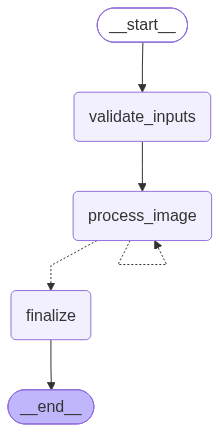

In [8]:
catalog_batch_pipeline